In [1]:
import pandas as pd 
df =pd.read_excel("C:/Users/raza0/Downloads/marketing_spend_waste_dataset.xlsx")
df.head()

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,Impressions,Customer_Rating,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI,High_Spend_Low_Conversion,Negative_ROI,Zero_Clicks
0,2024-04-12,North,Facebook Ads,Campaign_9,Clothing,663.16,7333.50,581.40,31,315,8141,3.09,32.32,6752.10,3.869304,2.105270,10.181706,False,False,False
1,2024-12-14,North,Affiliate,Campaign_14,Electronics,NaN,1871.79,1494.94,12,887,16529,4.34,35.20,376.85,5.366326,NaN,NaN,False,False,False
2,2024-09-27,North,Affiliate,Campaign_7,Books,861.93,2192.62,817.44,22,267,10193,4.97,9.78,1375.18,2.619445,3.228202,1.595466,False,False,False
3,2024-04-16,East,Facebook Ads,Campaign_6,Books,414.77,2298.41,311.93,62,315,5401,4.31,25.24,1986.48,5.832253,1.316730,4.789353,False,False,False
4,2024-03-12,East,Facebook Ads,NaN,Beauty,611.78,317.90,536.84,1,204,8723,2.67,23.17,-218.94,2.338645,2.998922,-0.357874,False,True,False


In [2]:
df.shape

(2200, 20)

In [3]:
df.columns

Index(['Date', 'Region', 'Marketing_Channel', 'Campaign_Name',
       'Product_Category', 'Marketing_Spend', 'Revenue', 'Cost', 'Conversions',
       'Clicks', 'Impressions', 'Customer_Rating', 'Discount_Rate (%)',
       'Profit', 'CTR(%)', 'CPC_clean', 'ROI', 'High_Spend_Low_Conversion',
       'Negative_ROI', 'Zero_Clicks'],
      dtype='object')

In [4]:
df.tail()

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,Impressions,Customer_Rating,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI,High_Spend_Low_Conversion,Negative_ROI,Zero_Clicks
2195,2024-12-27,North,Instagram Ads,Campaign_9,Home,57.46,484.47,51.19,31,450,490,4.85,18.59,433.28,91.836735,0.127689,7.540550,False,False,False
2196,2024-02-16,East,Google Ads,Campaign_19,Clothing,692.25,1771.50,668.13,57,339,7528,4.11,5.95,1103.37,4.503188,2.042035,1.593889,False,False,False
2197,2024-05-20,West,Instagram Ads,Campaign_9,Sports,294.30,713.07,301.01,6,167,2938,2.57,9.29,412.06,5.684139,1.762275,1.400136,False,False,False
2198,2024-04-27,South,YouTube Ads,Campaign_10,Clothing,3331.29,2095.25,3113.55,81,984,47789,3.75,8.36,-1018.30,2.059051,3.385457,-0.305677,False,True,False
2199,2024-10-03,East,Google Ads,Campaign_15,Sports,3276.94,17865.28,3788.48,154,1019,31482,3.67,37.47,14076.80,3.236770,3.215839,4.295715,False,False,False


In [5]:
df.dtypes

Date                         datetime64[ns]
Region                               object
Marketing_Channel                    object
Campaign_Name                        object
Product_Category                     object
Marketing_Spend                     float64
Revenue                             float64
Cost                                float64
Conversions                           int64
Clicks                                int64
Impressions                           int64
Customer_Rating                     float64
Discount_Rate (%)                   float64
Profit                              float64
CTR(%)                              float64
CPC_clean                           float64
ROI                                 float64
High_Spend_Low_Conversion              bool
Negative_ROI                           bool
Zero_Clicks                            bool
dtype: object

In [6]:
df.isnull().sum()

Date                         110
Region                       110
Marketing_Channel            110
Campaign_Name                110
Product_Category             110
Marketing_Spend              110
Revenue                      110
Cost                         110
Conversions                    0
Clicks                         0
Impressions                    0
Customer_Rating                0
Discount_Rate (%)              0
Profit                       217
CTR(%)                         0
CPC_clean                    110
ROI                          317
High_Spend_Low_Conversion      0
Negative_ROI                   0
Zero_Clicks                    0
dtype: int64

In [7]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

ROI                          14.409091
Profit                        9.863636
Date                          5.000000
Marketing_Channel             5.000000
Campaign_Name                 5.000000
Product_Category              5.000000
Marketing_Spend               5.000000
Revenue                       5.000000
Cost                          5.000000
Region                        5.000000
CPC_clean                     5.000000
CTR(%)                        0.000000
Negative_ROI                  0.000000
High_Spend_Low_Conversion     0.000000
Impressions                   0.000000
Discount_Rate (%)             0.000000
Customer_Rating               0.000000
Clicks                        0.000000
Conversions                   0.000000
Zero_Clicks                   0.000000
dtype: float64


In [8]:
df.shape

(2200, 20)

In [10]:
df=df.dropna(subset=["Revenue","Marketing_Spend","Cost"])

In [11]:
num_cols = ["Conversions", "Clicks", "Impressions", 
            "Customer_Rating", "Discount_Rate (%)"]

for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [12]:
df.isnull().sum()

Date                         96
Region                       95
Marketing_Channel            95
Campaign_Name                98
Product_Category             87
Marketing_Spend               0
Revenue                       0
Cost                          0
Conversions                   0
Clicks                        0
Impressions                   0
Customer_Rating               0
Discount_Rate (%)             0
Profit                        0
CTR(%)                        0
CPC_clean                     0
ROI                           0
High_Spend_Low_Conversion     0
Negative_ROI                  0
Zero_Clicks                   0
dtype: int64

In [13]:
df["profit_clean"]= df["Revenue"]-df["Cost"]
df.head()

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,...,Customer_Rating,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI,High_Spend_Low_Conversion,Negative_ROI,Zero_Clicks,profit_clean
0,2024-04-12,North,Facebook Ads,Campaign_9,Clothing,663.16,7333.50,581.40,31,315,...,3.09,32.32,6752.10,3.869304,2.105270,10.181706,False,False,False,6752.10
2,2024-09-27,North,Affiliate,Campaign_7,Books,861.93,2192.62,817.44,22,267,...,4.97,9.78,1375.18,2.619445,3.228202,1.595466,False,False,False,1375.18
3,2024-04-16,East,Facebook Ads,Campaign_6,Books,414.77,2298.41,311.93,62,315,...,4.31,25.24,1986.48,5.832253,1.316730,4.789353,False,False,False,1986.48
4,2024-03-12,East,Facebook Ads,NaN,Beauty,611.78,317.90,536.84,1,204,...,2.67,23.17,-218.94,2.338645,2.998922,-0.357874,False,True,False,-218.94
5,2024-07-07,North,YouTube Ads,Campaign_15,Sports,1286.89,1314.69,1540.49,8,493,...,4.15,24.52,-225.80,3.265766,2.610325,-0.175462,True,True,False,-225.80


In [14]:
df["CTR_clean(%)"]=(df["Clicks"] / df["Impressions"])*100

In [15]:
df["CPC_clean"]=df["Marketing_Spend"]/df["Clicks"]

In [16]:
df.head()

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,...,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI,High_Spend_Low_Conversion,Negative_ROI,Zero_Clicks,profit_clean,CTR_clean(%)
0,2024-04-12,North,Facebook Ads,Campaign_9,Clothing,663.16,7333.50,581.40,31,315,...,32.32,6752.10,3.869304,2.105270,10.181706,False,False,False,6752.10,3.869304
2,2024-09-27,North,Affiliate,Campaign_7,Books,861.93,2192.62,817.44,22,267,...,9.78,1375.18,2.619445,3.228202,1.595466,False,False,False,1375.18,2.619445
3,2024-04-16,East,Facebook Ads,Campaign_6,Books,414.77,2298.41,311.93,62,315,...,25.24,1986.48,5.832253,1.316730,4.789353,False,False,False,1986.48,5.832253
4,2024-03-12,East,Facebook Ads,NaN,Beauty,611.78,317.90,536.84,1,204,...,23.17,-218.94,2.338645,2.998922,-0.357874,False,True,False,-218.94,2.338645
5,2024-07-07,North,YouTube Ads,Campaign_15,Sports,1286.89,1314.69,1540.49,8,493,...,24.52,-225.80,3.265766,2.610325,-0.175462,True,True,False,-225.80,3.265766


In [17]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [24]:
df.head()

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,...,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI,High_Spend_Low_Conversion,Negative_ROI,Zero_Clicks,profit_clean,CTR_clean(%)
0,2024-04-12,North,Facebook Ads,Campaign_9,Clothing,663.16,7333.50,581.40,31,315,...,32.32,6752.10,3.869304,2.105270,10.181706,False,False,False,6752.10,3.869304
2,2024-09-27,North,Affiliate,Campaign_7,Books,861.93,2192.62,817.44,22,267,...,9.78,1375.18,2.619445,3.228202,1.595466,False,False,False,1375.18,2.619445
3,2024-04-16,East,Facebook Ads,Campaign_6,Books,414.77,2298.41,311.93,62,315,...,25.24,1986.48,5.832253,1.316730,4.789353,False,False,False,1986.48,5.832253
4,2024-03-12,East,Facebook Ads,NaN,Beauty,611.78,317.90,536.84,1,204,...,23.17,-218.94,2.338645,2.998922,-0.357874,False,True,False,-218.94,2.338645
5,2024-07-07,North,YouTube Ads,Campaign_15,Sports,1286.89,1314.69,1540.49,8,493,...,24.52,-225.80,3.265766,2.610325,-0.175462,True,True,False,-225.80,3.265766


In [25]:
df.rename(columns={
    "profit_clean":"Profit",
    "CTR_clean(%)":"CTR(%)",
    "CPR_clean":"CPC"
},inplace=True)

In [26]:
df.head()

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,...,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI,High_Spend_Low_Conversion,Negative_ROI,Zero_Clicks,Profit,CTR(%)
0,2024-04-12,North,Facebook Ads,Campaign_9,Clothing,663.16,7333.50,581.40,31,315,...,32.32,6752.10,3.869304,2.105270,10.181706,False,False,False,6752.10,3.869304
2,2024-09-27,North,Affiliate,Campaign_7,Books,861.93,2192.62,817.44,22,267,...,9.78,1375.18,2.619445,3.228202,1.595466,False,False,False,1375.18,2.619445
3,2024-04-16,East,Facebook Ads,Campaign_6,Books,414.77,2298.41,311.93,62,315,...,25.24,1986.48,5.832253,1.316730,4.789353,False,False,False,1986.48,5.832253
4,2024-03-12,East,Facebook Ads,NaN,Beauty,611.78,317.90,536.84,1,204,...,23.17,-218.94,2.338645,2.998922,-0.357874,False,True,False,-218.94,2.338645
5,2024-07-07,North,YouTube Ads,Campaign_15,Sports,1286.89,1314.69,1540.49,8,493,...,24.52,-225.80,3.265766,2.610325,-0.175462,True,True,False,-225.80,3.265766


In [27]:
df.isnull().sum()

Date                         96
Region                       95
Marketing_Channel            95
Campaign_Name                98
Product_Category             87
Marketing_Spend               0
Revenue                       0
Cost                          0
Conversions                   0
Clicks                        0
Impressions                   0
Customer_Rating               0
Discount_Rate (%)             0
Profit                        0
CTR(%)                        0
CPC_clean                     0
ROI                           0
High_Spend_Low_Conversion     0
Negative_ROI                  0
Zero_Clicks                   0
Profit                        0
CTR(%)                        0
dtype: int64

In [48]:
df.head(20)

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,Impressions,Customer_Rating,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI
0,2024-04-12,North,Facebook Ads,Campaign_9,Clothing,663.16,7333.50,581.40,31.0,315.0,8141.0,3.09,32.32,6752.10,3.869304,2.105270,10.181706
1,2024-12-14,North,Affiliate,Campaign_14,Electronics,NaN,1871.79,1494.94,12.0,887.0,16529.0,4.34,35.20,376.85,5.366326,NaN,NaN
2,2024-09-27,North,Affiliate,Campaign_7,Books,861.93,2192.62,817.44,22.0,267.0,10193.0,4.97,9.78,1375.18,2.619445,3.228202,1.595466
3,2024-04-16,East,Facebook Ads,Campaign_6,Books,414.77,2298.41,311.93,62.0,315.0,5401.0,4.31,25.24,1986.48,5.832253,1.316730,4.789353
4,2024-03-12,East,Facebook Ads,NaN,Beauty,611.78,317.90,536.84,1.0,204.0,8723.0,2.67,23.17,-218.94,2.338645,2.998922,-0.357874
5,2024-07-07,North,YouTube Ads,Campaign_15,Sports,1286.89,1314.69,1540.49,8.0,493.0,15096.0,4.15,24.52,-225.80,3.265766,2.610325,-0.175462
6,2024-01-21,East,YouTube Ads,Campaign_20,NaN,1034.04,1162.57,956.68,35.0,319.0,13266.0,4.39,17.17,205.89,2.404643,3.241505,0.199112
7,2024-04-12,South,Instagram Ads,Campaign_3,Clothing,1754.91,3728.56,2041.84,31.0,642.0,16921.0,3.85,34.47,1686.72,3.794102,2.733505,0.961143
8,2024-05-01,East,Google Ads,Campaign_12,Home,3405.97,17409.94,NaN,143.0,857.0,45254.0,2.59,15.61,NaN,1.893755,3.974294,NaN
9,2024-08-02,North,Affiliate,Campaign_6,Sports,421.98,1459.87,389.74,20.0,299.0,6143.0,4.00,23.05,1070.13,4.867329,1.411304,2.535973


In [49]:
df["ROI"].describe()

count    1883.000000
mean        3.088161
std         4.075100
min        -1.141172
25%         0.167459
50%         1.626647
75%         4.616041
max        25.508458
Name: ROI, dtype: float64

In [50]:
channel_analysis = df.groupby("Marketing_Channel").agg({
    "Marketing_Spend": "sum",
    "Revenue": "sum",
    "Profit": "sum",
    "ROI": "mean"
}).sort_values(by="ROI")

print(channel_analysis)

                   Marketing_Spend     Revenue      Profit       ROI
Marketing_Channel                                                   
YouTube Ads              468954.87  1646570.77  1191897.97  2.877370
Affiliate                452216.92  1532092.56  1113422.22  2.915702
Google Ads               471220.16  1721852.02  1211028.33  2.919002
Instagram Ads            469744.68  1800118.53  1281886.33  2.974894
Email                    446109.91  1776627.50  1346539.08  3.217073
Facebook Ads             509967.96  1999721.47  1540608.51  3.537066


In [51]:
df["High_Spend_Low_Conversion"] = (
    (df["Marketing_Spend"] > df["Marketing_Spend"].median()) &
    (df["Conversions"] < df["Conversions"].median())
)

df["Negative_ROI"] = df["ROI"] < 0

df["Zero_Clicks"] = df["Clicks"] == 0

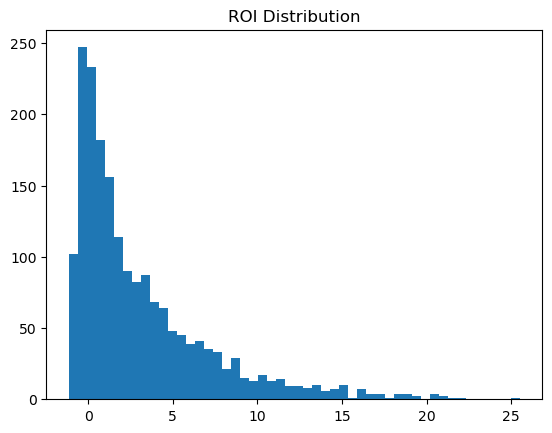

In [53]:
import matplotlib.pyplot as plt

plt.hist(df["ROI"], bins=50)
plt.title("ROI Distribution")
plt.show()

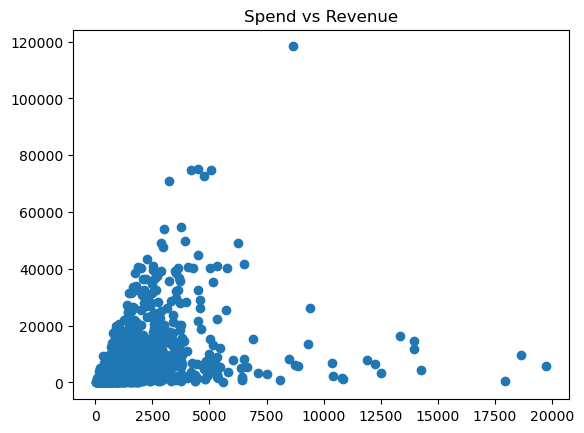

In [54]:
plt.scatter(df["Marketing_Spend"], df["Revenue"])
plt.title("Spend vs Revenue")
plt.show()

In [55]:
df.head()

,Date,Region,Marketing_Channel,Campaign_Name,Product_Category,Marketing_Spend,Revenue,Cost,Conversions,Clicks,Impressions,Customer_Rating,Discount_Rate (%),Profit,CTR(%),CPC_clean,ROI,High_Spend_Low_Conversion,Negative_ROI,Zero_Clicks
0,2024-04-12,North,Facebook Ads,Campaign_9,Clothing,663.16,7333.50,581.40,31.0,315.0,8141.0,3.09,32.32,6752.10,3.869304,2.105270,10.181706,False,False,False
1,2024-12-14,North,Affiliate,Campaign_14,Electronics,NaN,1871.79,1494.94,12.0,887.0,16529.0,4.34,35.20,376.85,5.366326,NaN,NaN,False,False,False
2,2024-09-27,North,Affiliate,Campaign_7,Books,861.93,2192.62,817.44,22.0,267.0,10193.0,4.97,9.78,1375.18,2.619445,3.228202,1.595466,False,False,False
3,2024-04-16,East,Facebook Ads,Campaign_6,Books,414.77,2298.41,311.93,62.0,315.0,5401.0,4.31,25.24,1986.48,5.832253,1.316730,4.789353,False,False,False
4,2024-03-12,East,Facebook Ads,NaN,Beauty,611.78,317.90,536.84,1.0,204.0,8723.0,2.67,23.17,-218.94,2.338645,2.998922,-0.357874,False,True,False


In [56]:
(df["Negative_ROI"].sum() / len(df)) * 100

np.float64(17.40909090909091)

In [2]:
import os
os.getcwd()

'C:\\Users\\raza0'

In [6]:
# Export the dataframe to a new Excel file
df.to_excel("marketing_spend_report_updated.xlsx", index=False)

print("File has been exported successfully!")

File has been exported successfully!


In [7]:
# Save the current dataframe to an Excel file
df.to_excel("marketing_spend_analysis.xlsx", index=False)

print("Success! Your file is saved in: " + os.getcwd())

Success! Your file is saved in: C:\Users\raza0
